# Flood Classification — Visualise, Split, Train & Save
Project-derived daily flood-risk classes: **Low, Medium, High**.

Training: **2023–2025**  
Testing: **2026**

Models: **Gradient Boosting, CART, ID3-style Entropy Tree**.


In [1]:
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, joblib
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

R=Path.cwd(); R=R if R.name.lower()=="flood" else (R/"Flood" if (R/"Flood").exists() else R.parent/"Flood")
D=R/"dataset"/"flood_preprocessed.csv"; M=R/"trained_models"; M.mkdir(exist_ok=True)

F=[
    "rain_sum_past_3day",
    "rain_sum_past_7day",
    "max_daily_rain_past_7day",
    "precipitation_hours_past_7day",
    "river_discharge_previous_day",
    "river_discharge_mean_7day",
    "river_discharge_median_7day",
    "river_discharge_max_7day",
    "discharge_ratio",
    "elevation",
    "month"
]
T="flood_class"; C=["Low","Medium","High"]

df=pd.read_csv(D); df["date"]=pd.to_datetime(df.date)
print(df.shape,df.date.min(),df.date.max()); display(df.head()); display(df[F+[T]].isna().sum().to_frame("missing"))


(380482, 29) 2021-01-08 00:00:00 2026-01-31 00:00:00


,date,town,rain_sum,precipitation_hours,elevation,river_discharge,rain_sum_past_3day,rain_sum_past_7day,max_daily_rain_past_7day,rain_flag_50mm,...,cond_precipitation_hours,cond_discharge_absolute,cond_discharge_mean,cond_discharge_max,cond_discharge_ratio,rain_condition_score,river_condition_score,flood_condition_score,flood_class,month
0,2021-01-18,Nagoya,0.1,1.0,23.0,0.66,0.6,3.7,3.1,0,...,0,0,0,0,0,0,0,0,Low,1
1,2021-01-19,Nagoya,0.2,2.0,23.0,0.64,0.7,3.8,3.1,0,...,0,0,0,0,0,0,0,0,Low,1
2,2021-01-20,Nagoya,0.0,0.0,23.0,0.61,0.3,0.9,0.6,0,...,0,0,0,0,0,0,0,0,Low,1
3,2021-01-21,Nagoya,0.0,0.0,23.0,0.59,0.3,0.9,0.6,0,...,0,0,0,0,0,0,0,0,Low,1
4,2021-01-22,Nagoya,1.9,10.0,23.0,1.97,0.2,0.9,0.6,0,...,0,0,0,0,0,0,0,0,Low,1


,missing
rain_sum_past_3day,0
rain_sum_past_7day,0
max_daily_rain_past_7day,0
precipitation_hours_past_7day,0
river_discharge_previous_day,0
river_discharge_mean_7day,0
river_discharge_median_7day,0
river_discharge_max_7day,0
discharge_ratio,0
elevation,0


## Plot 1 — Class distribution
Check Low / Medium / High class imbalance before training.


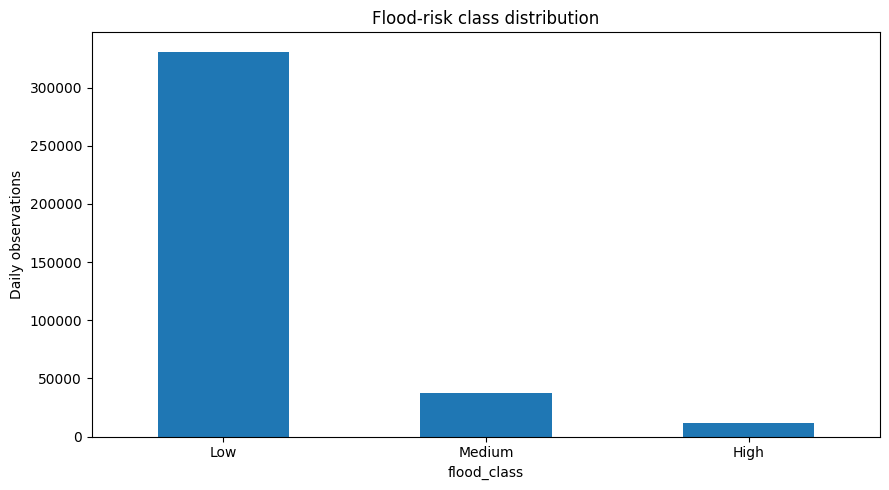

,count,percent
flood_class,,
Low,330971,86.99
Medium,37457,9.84
High,12054,3.17


In [2]:
counts=df[T].value_counts().reindex(C,fill_value=0); counts.plot(kind="bar",figsize=(9,5)); plt.title("Flood-risk class distribution"); plt.ylabel("Daily observations"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
display(pd.DataFrame({"count":counts,"percent":(100*counts/counts.sum()).round(2)}))


## Plot 2 — 3-day rainfall distribution
Inspect the distribution of accumulated rainfall during the previous three complete days.


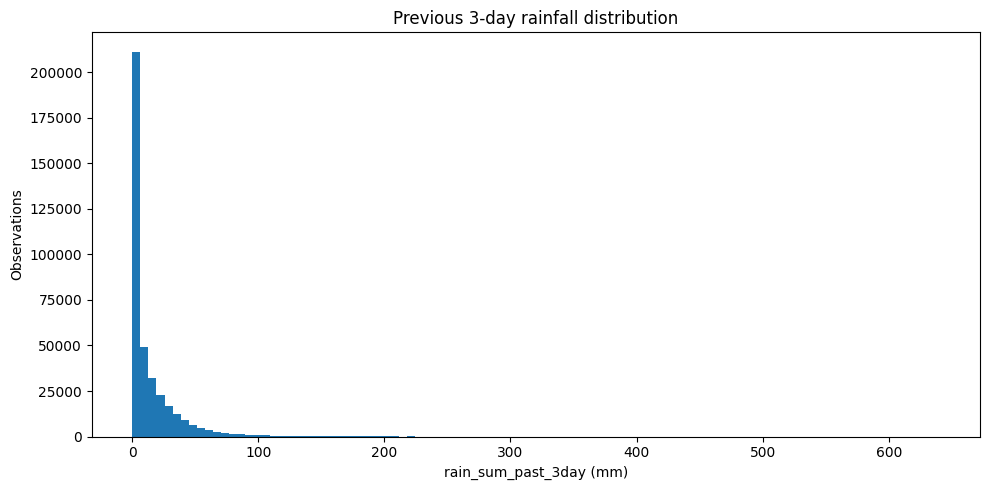

count    380482.000000
mean         13.450916
std          22.621270
min           0.000000
50%           4.600000
75%          17.600000
90%          37.400000
95%          53.900000
99%         102.500000
99.5%       129.400000
99.9%       213.100000
max         640.400000
Name: rain_sum_past_3day, dtype: float64

In [3]:
plt.figure(figsize=(10,5)); plt.hist(df.rain_sum_past_3day.dropna(),bins=100); plt.title("Previous 3-day rainfall distribution"); plt.xlabel("rain_sum_past_3day (mm)"); plt.ylabel("Observations"); plt.tight_layout(); plt.show()
display(df.rain_sum_past_3day.describe(percentiles=[.5,.75,.9,.95,.99,.995,.999]))


## Plot 3 — Monthly class distribution


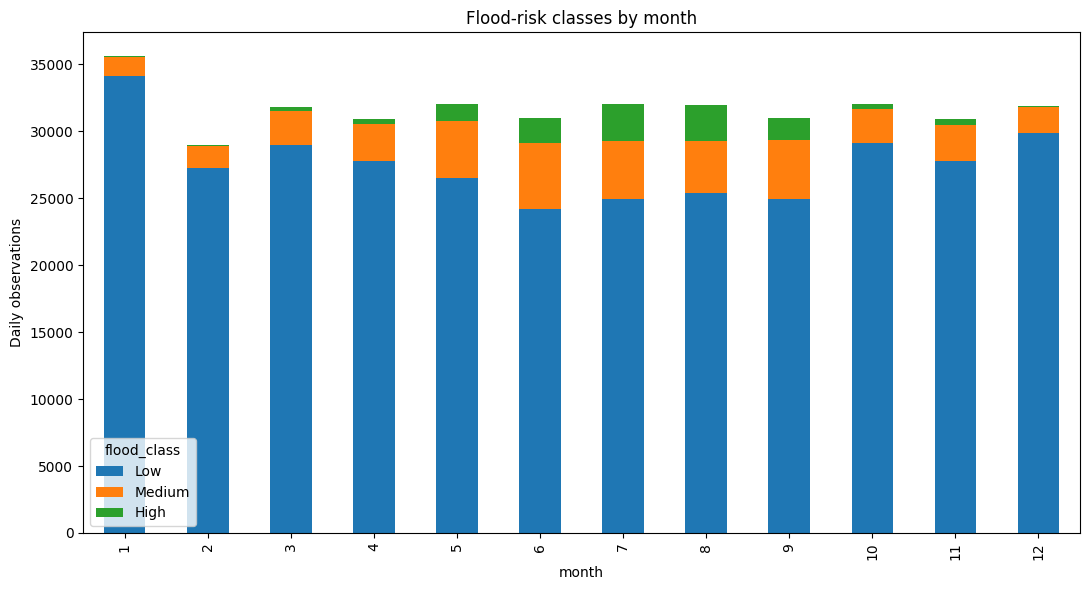

In [4]:
pd.crosstab(df.month,df[T]).reindex(columns=C,fill_value=0).plot(kind="bar",stacked=True,figsize=(11,6)); plt.title("Flood-risk classes by month"); plt.ylabel("Daily observations"); plt.tight_layout(); plt.show()


## Plot 4 — Correlation heatmap


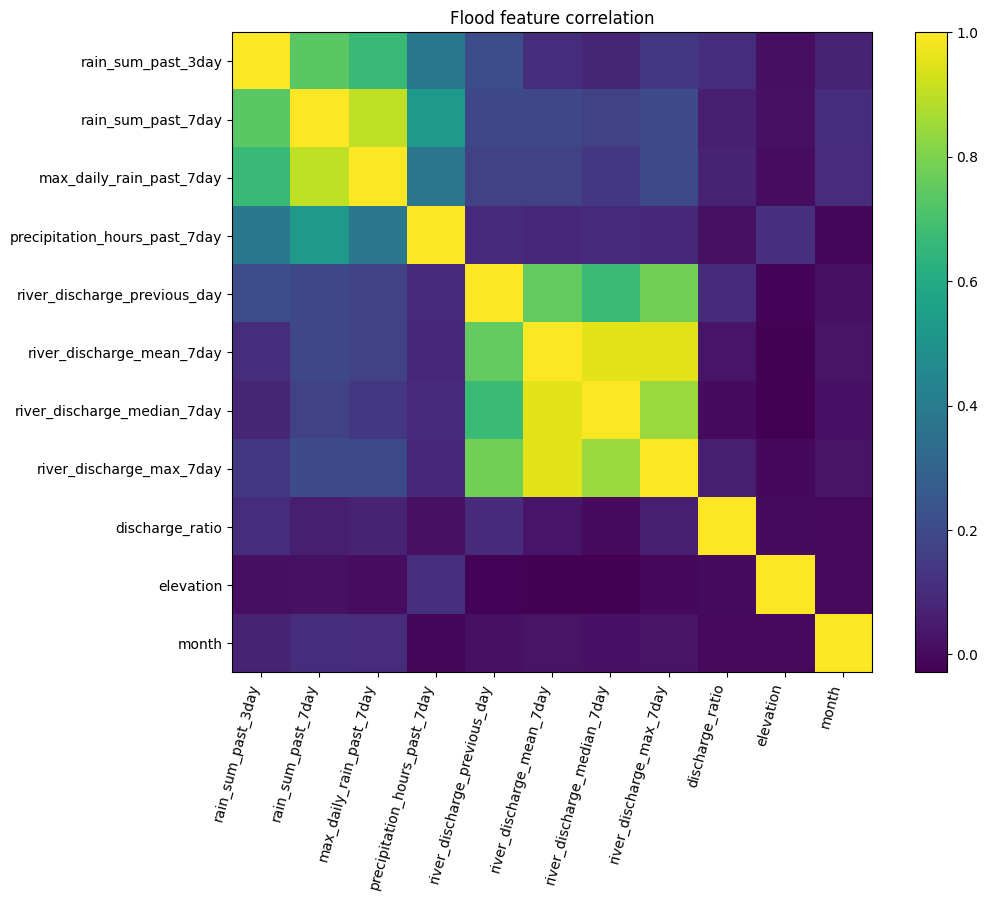

In [5]:
corr=df[F].corr(); fig,ax=plt.subplots(figsize=(11,9)); im=ax.imshow(corr); ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr))); ax.set_xticklabels(corr.columns,rotation=75,ha="right"); ax.set_yticklabels(corr.columns); fig.colorbar(im,ax=ax); plt.title("Flood feature correlation"); plt.tight_layout(); plt.show()


## Chronological split
**2023–2025 = training; 2026 = testing.**

The condition flag/score columns used during label construction are not included in `F`.


In [6]:
req=F+[T,"date"]; missing=[c for c in req if c not in df]; assert not missing,f"Missing: {missing}"
d=df.dropna(subset=req).copy(); train=d[d.date.dt.year.between(2023,2025)].copy(); test=d[d.date.dt.year==2026].copy()
assert len(train) and len(test),"Need 2023-2025 training data and 2026 testing data"
Xtr,ytr=train[F],train[T]; Xte,yte=test[F],test[T]
train.to_csv(M/"training.csv",index=False); test.to_csv(M/"testing.csv",index=False)
print("Train",len(train),train.date.min(),train.date.max()); print("Test",len(test),test.date.min(),test.date.max())
display(pd.DataFrame({"train":ytr.value_counts().reindex(C,fill_value=0),"test":yte.value_counts().reindex(C,fill_value=0)}))


Train 225980 2023-01-01 00:00:00 2025-12-31 00:00:00
Test 6293 2026-01-01 00:00:00 2026-01-31 00:00:00


,train,test
flood_class,,
Low,198035,6101
Medium,21483,190
High,6462,2


## Train three classifiers


In [7]:
models={
    "Gradient Boosting":GradientBoostingClassifier(random_state=42),
    "CART":DecisionTreeClassifier(random_state=42,class_weight="balanced"),
    "ID3-style Entropy Tree":DecisionTreeClassifier(criterion="entropy",random_state=42,class_weight="balanced")
}
rows=[]; preds={}
for name,m in models.items():
 print("Training",name); m.fit(Xtr,ytr); p=m.predict(Xte); preds[name]=p
 rows.append({"Model":name,"Accuracy":accuracy_score(yte,p),"Macro Precision":precision_score(yte,p,average="macro",zero_division=0),"Macro Recall":recall_score(yte,p,average="macro",zero_division=0),"Macro F1":f1_score(yte,p,average="macro",zero_division=0)})
results=pd.DataFrame(rows).sort_values("Macro F1",ascending=False); display(results)


Training Gradient Boosting
Training CART
Training ID3-style Entropy Tree


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,CART,1.000000,1.000000,1.000000,1.000000
2,ID3-style Entropy Tree,1.000000,1.000000,1.000000,1.000000
0,Gradient Boosting,0.999841,0.999945,0.998246,0.999093


## Detailed reports and confusion matrices



 Gradient Boosting
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      6101
      Medium       1.00      0.99      1.00       190
        High       1.00      1.00      1.00         2

    accuracy                           1.00      6293
   macro avg       1.00      1.00      1.00      6293
weighted avg       1.00      1.00      1.00      6293



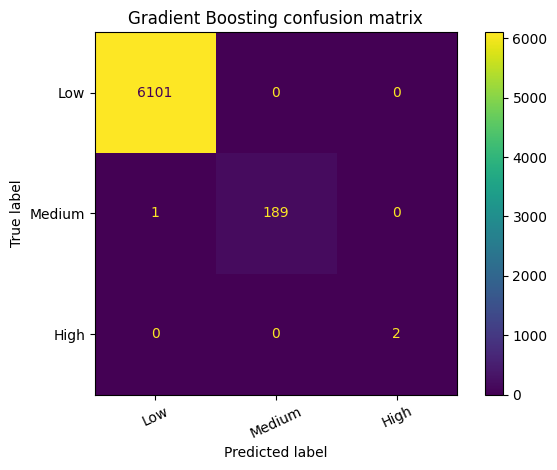


 CART
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      6101
      Medium       1.00      1.00      1.00       190
        High       1.00      1.00      1.00         2

    accuracy                           1.00      6293
   macro avg       1.00      1.00      1.00      6293
weighted avg       1.00      1.00      1.00      6293



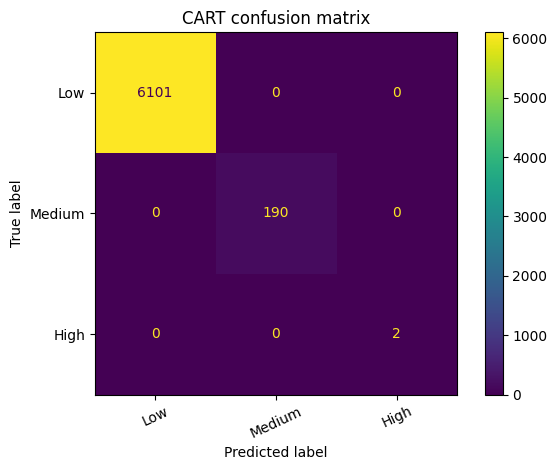


 ID3-style Entropy Tree
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      6101
      Medium       1.00      1.00      1.00       190
        High       1.00      1.00      1.00         2

    accuracy                           1.00      6293
   macro avg       1.00      1.00      1.00      6293
weighted avg       1.00      1.00      1.00      6293



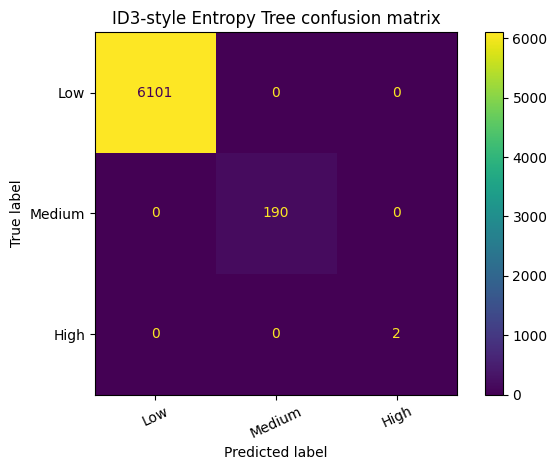

In [8]:
for name,p in preds.items():
 print("\n",name); print(classification_report(yte,p,labels=C,zero_division=0))
 ConfusionMatrixDisplay.from_predictions(yte,p,labels=C,xticks_rotation=25); plt.title(name+" confusion matrix"); plt.tight_layout(); plt.show()


## Feature importance


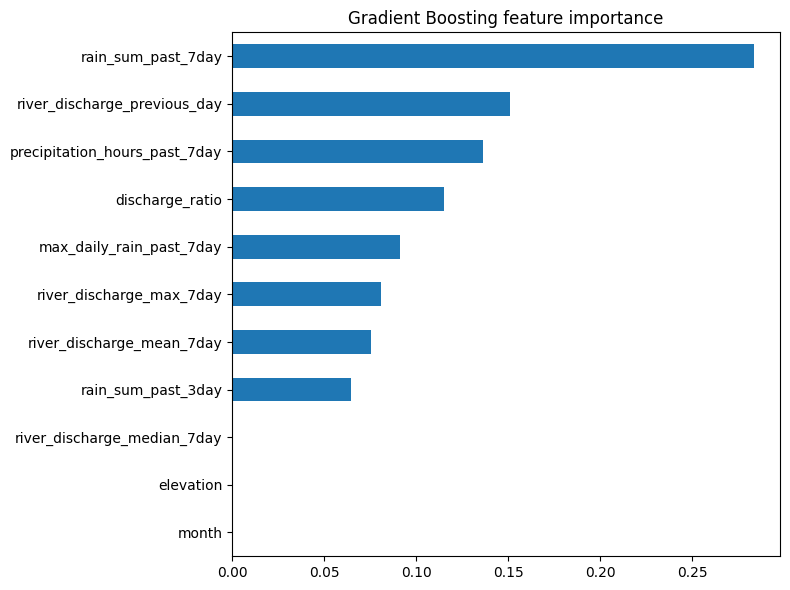

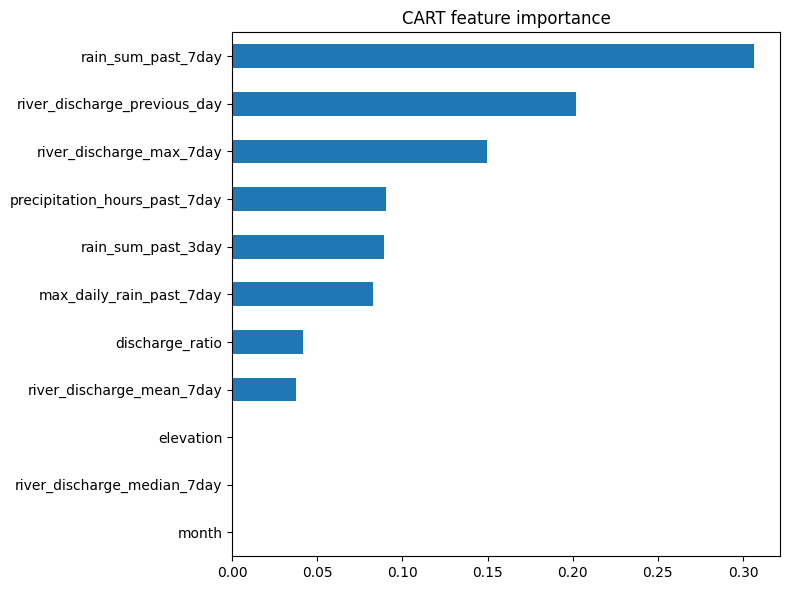

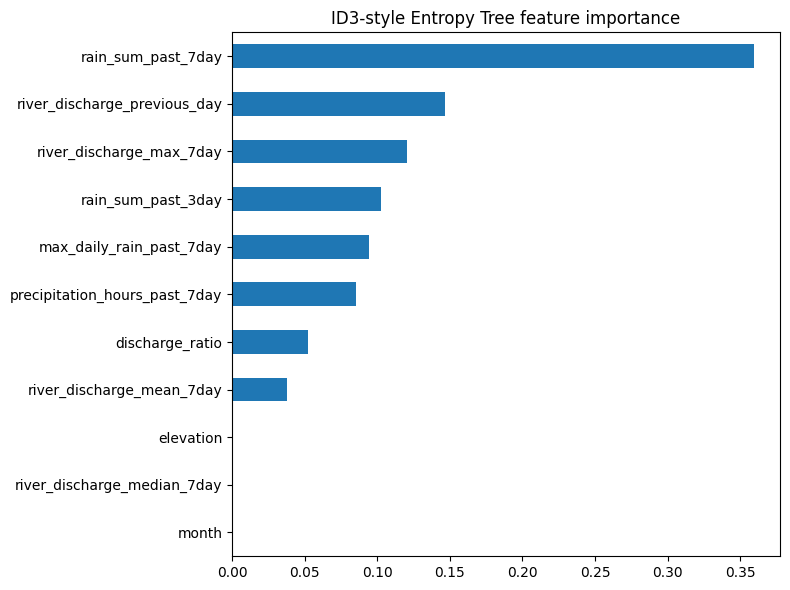

In [9]:
for name in ["Gradient Boosting","CART","ID3-style Entropy Tree"]:
 pd.Series(models[name].feature_importances_,index=F).sort_values().plot(kind="barh",figsize=(8,6)); plt.title(name+" feature importance"); plt.tight_layout(); plt.show()


## Save models and results


In [10]:
names={"Gradient Boosting":"gradient_boosting_flood.joblib","CART":"cart_flood.joblib","ID3-style Entropy Tree":"id3_flood.joblib"}
for n,m in models.items(): joblib.dump(m,M/names[n]); print("Saved",M/names[n])
results.to_csv(M/"model_results.csv",index=False); print("Done:",M)


Saved c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Flood\trained_models\gradient_boosting_flood.joblib
Saved c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Flood\trained_models\cart_flood.joblib
Saved c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Flood\trained_models\id3_flood.joblib
Done: c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Flood\trained_models
